

## Pandas - Combining Dataframes


<br>

## 1. Intro

Real-world data is rarely in a single table. In this unit, we'll explore 2 common ways of combining dataframes in Pandas: `pd.concat()`, and `pd.merge()`

Here's a table with the main use cases for them:

| Tool | What it does | When to use it |
|------|-------------|----------------|
| `pd.concat` | Stacks DataFrames by position (rows or columns) | Same structure, more data |
| `pd.merge` | Joins DataFrames by matching key values | Different info about the same entities |


<br>

## 2. Concat


### 2.1 Intro

`pd.concat` is used to **combine multiple DataFrames** by stacking them together — either vertically (adding rows) or horizontally (adding columns).

It is most useful when you have data split across multiple DataFrames with the same structure, such as:
- Monthly sales data in separate files
- Data from different sources with the same columns

<br>

### 2.2 Basic Syntax

```python
pd.concat([df1, df2, ...])
```

- The main argument is a **list of DataFrames** to combine.
- By default, DataFrames are stacked **vertically** (rows on top of each other).

In [1]:
import pandas as pd

# Two small DataFrames with the same structure
df1 = pd.DataFrame({'name': ['Alice', 'Bob'], 'score': [85, 90]})
df2 = pd.DataFrame({'name': ['Carol', 'Dave'], 'score': [78, 95]})

display(df1)
display(df2)

,name,score
0,Alice,85
1,Bob,90


,name,score
0,Carol,78
1,Dave,95


In [2]:
# Let's put them together

result = pd.concat([df1, df2])
result

,name,score
0,Alice,85
1,Bob,90
0,Carol,78
1,Dave,95


<br>

### 2.3 Resetting the Index

After concatenating, the original indexes are preserved — which can result in **duplicate index values**.

Use `reset_index(drop=True)` to get a clean, continuous index.

In [3]:
result_1 = pd.concat([df1, df2])
display(result_1)

# reset_index()
result_2 = pd.concat([df1, df2]).reset_index()
display(result_2)

# .reset_index(drop=True) - the old index is simply discarded
result_3 = pd.concat([df1, df2]).reset_index(drop=True)
display(result_3)

,name,score
0,Alice,85
1,Bob,90
0,Carol,78
1,Dave,95


,index,name,score
0,0,Alice,85
1,1,Bob,90
2,0,Carol,78
3,1,Dave,95


,name,score
0,Alice,85
1,Bob,90
2,Carol,78
3,Dave,95


<br>

### 2.4 Stacking Rows vs Columns

The `axis` parameter controls the direction of concatenation:

| `axis` | Direction | Result |
|--------|-----------|--------|
| `0` (default) | Vertical | Adds rows — DataFrames are stacked on top of each other |
| `1` | Horizontal | Adds columns — DataFrames are placed side by side |

In [24]:
# 
# axis=0 (default) — stack rows vertically
# 

users_1 = pd.DataFrame({'name': ['Alice', 'Bob'], 'city': ["Berlin", "Paris"]})
users_2 = pd.DataFrame({'name': ['Carol', 'Dave'], 'city': ["Bilbao", "Lisbon"]})

display(users_1)
display(users_2)

all_users = pd.concat([users_1, users_2], axis=0)
display(all_users)


,name,city
0,Alice,Berlin
1,Bob,Paris


,name,city
0,Carol,Bilbao
1,Dave,Lisbon


,name,city
0,Alice,Berlin
1,Bob,Paris
0,Carol,Bilbao
1,Dave,Lisbon


In [5]:
#
# axis=1 — stack columns horizontally
#

# User info and account details are stored in separate DataFrames
user_info = pd.DataFrame({'name': ['Alice', 'Bob', 'Carol'], 'city': ['Berlin', 'Paris', 'Lisbon']})
user_accounts = pd.DataFrame({'email': ['alice@email.com', 'bob@email.com', 'carol@email.com'], 'plan': ['pro', 'free', 'pro']})

display(user_info)
display(user_accounts)

# Combine side by side
users_full = pd.concat([user_info, user_accounts], axis=1)
display(users_full)

,name,city
0,Alice,Berlin
1,Bob,Paris
2,Carol,Lisbon


,email,plan
0,alice@email.com,pro
1,bob@email.com,free
2,carol@email.com,pro


,name,city,email,plan
0,Alice,Berlin,alice@email.com,pro
1,Bob,Paris,bob@email.com,free
2,Carol,Lisbon,carol@email.com,pro


<br>

Note: `pd.concat(..., axis=1)` matches and combines rows strictly by their index labels, filling in NaN if any index doesn't match.


<br>

### 2.5 Handling Mismatched Columns

When the DataFrames don't have the same columns, `pd.concat` fills the gaps with `NaN` by default.

You can control this with the `join` parameter:
- `join='outer'` (default) — keeps **all columns**, filling missing values with `NaN`
- `join='inner'` — keeps only **columns that appear in all DataFrames**

In [26]:
# Both DataFrames share 'name' and 'plan', but each has one unique column
users_eu = pd.DataFrame({'name': ['Alice', 'Bob'], 'plan': ['pro', 'free'], 'city': ['Berlin', 'Paris']})
users_us = pd.DataFrame({'name': ['Carol', 'Dave'], 'plan': ['pro', 'pro'], 'state': ['NY', 'CA']})

display(users_eu)
display(users_us)

# join='outer' (default) — keeps all columns, NaN where data is missing
print("\n\n join='outer':")
display(pd.concat([users_eu, users_us], join='outer'))

# join='inner' — keeps only shared columns ('name' and 'plan')
print("\n\n join='inner':")
display(pd.concat([users_eu, users_us], join='inner'))

,name,plan,city
0,Alice,pro,Berlin
1,Bob,free,Paris


,name,plan,state
0,Carol,pro,NY
1,Dave,pro,CA




 join='outer':


,name,plan,city,state
0,Alice,pro,Berlin,NaN
1,Bob,free,Paris,NaN
0,Carol,pro,NaN,NY
1,Dave,pro,NaN,CA




 join='inner':


,name,plan
0,Alice,pro
1,Bob,free
0,Carol,pro
1,Dave,pro



---

<br><br>

## 3. Merge



### 3.1 Intro

In real-world projects, data is often split across multiple tables or files.

For example, one table might contain customer information, while another contains their orders. A shared column, such as customer_id, connects the two. (Organizing data into related tables like this is a common pattern in relational databases known as "normalization")

<br>

![pandas-merge-01](../images/pandas-merge-01.jpeg)

(Image source: [gcpstudyhub](https://gcpstudyhub.com/blog/normalization-vs-denormalization-in-bigquery))

<br>

**`pd.merge()` lets you combine two DataFrames based on common columns** (by matching rows with the same value in one or more columns).

Note: If you're familiar with SQL, `pd.merge()` lets you perform operations similar to SQL JOINs.

<br>

![pandas-merge-02](../images/pandas-merge-02.webp)

(Image source: [geeksforgeeks](https://www.geeksforgeeks.org/python/joining-two-pandas-dataframes-using-merge/)

<br>


Use `pd.merge()` when you have data spread across two tables that share a common identifier (e.g. `user_id`, `order_id`).

**`concat` vs `merge`:**
| | `pd.concat` | `pd.merge` |
|---|---|---|
| How it combines | Stacks DataFrames by position | Combine DataFrames using a common column (the dfs usually have different colums, but need to share a key column) |
| Requires shared keys? | No | Yes |
| Use case | Same structure (you just need to add more rows or cols) | Different info about the same entities |



<br>

### 3.2 Basic Syntax

```python
pd.merge(left, right, on='key', how='inner')
```

| Parameter | Description |
|-----------|-------------|
| `left`, `right` | The two DataFrames to join |
| `on` | Column name(s) to join on (must exist in both) |
| `how` | Type of join: `'inner'`, `'left'`, `'right'`, `'outer'` (default: `'inner'`) |


In [18]:
#
# Let's prepare some sample data
#

users = pd.DataFrame({ 'user_id': [1, 2, 3], 'name':    ['Alice', 'Bob', 'Carol']})
orders = pd.DataFrame({ 'user_id': [1, 2, 4], 'product': ['Laptop', 'Phone', 'Tablet']})

display(users)
display(orders)


,user_id,name
0,1,Alice
1,2,Bob
2,3,Carol


,user_id,product
0,1,Laptop
1,2,Phone
2,4,Tablet


In [19]:

pd.merge(users, orders, on='user_id')


,user_id,name,product
0,1,Alice,Laptop
1,2,Bob,Phone



<br>

### 3.3 Join Types

The `how` parameter controls which rows are kept when keys don't match.

| `how` | Keeps... | Fills unmatched with |
|-------|--------------------|----------------------|
| `'inner'` (default) | Keep only rows with matching keys in both tables | — (unmatched rows are dropped) |
| `'left'` | Keep all rows from *left* dataframe | `NaN` for right columns |
| `'right'` | Keep all rows from *right* dataframe | `NaN` for left columns |
| `'outer'` | Keep all rows from *both* dataframes | `NaN` for missing values |

Using the same `users` and `orders` DataFrames from above:


<br>


![pandas-merge-03](../images/pandas-merge-03.png)

(Image source: [practicaldatascience](https://practicaldatascience.org/notebooks/class_3/week_4/15.1_combining_merging_continued.html)

<br>


In [9]:

# inner — only users who have an order (user 3 and order 4 are dropped)
print("inner:")
display(pd.merge(users, orders, on='user_id', how='inner'))

# left — all users, NaN where there is no matching order (user 3 has no order)
print("left:")
display(pd.merge(users, orders, on='user_id', how='left'))

# right — all orders, NaN where there is no matching user (order for user 4 has no name)
print("right:")
display(pd.merge(users, orders, on='user_id', how='right'))

# outer — everyone, filling NaN where data is missing
print("outer:")
display(pd.merge(users, orders, on='user_id', how='outer'))


inner:


,user_id,name,product
0,1,Alice,Laptop
1,2,Bob,Phone


left:


,user_id,name,product
0,1,Alice,Laptop
1,2,Bob,Phone
2,3,Carol,NaN


right:


,user_id,name,product
0,1,Alice,Laptop
1,2,Bob,Phone
2,4,NaN,Tablet


outer:


,user_id,name,product
0,1,Alice,Laptop
1,2,Bob,Phone
2,3,Carol,NaN
3,4,NaN,Tablet



<br>

Here’s a useful cheatsheet:

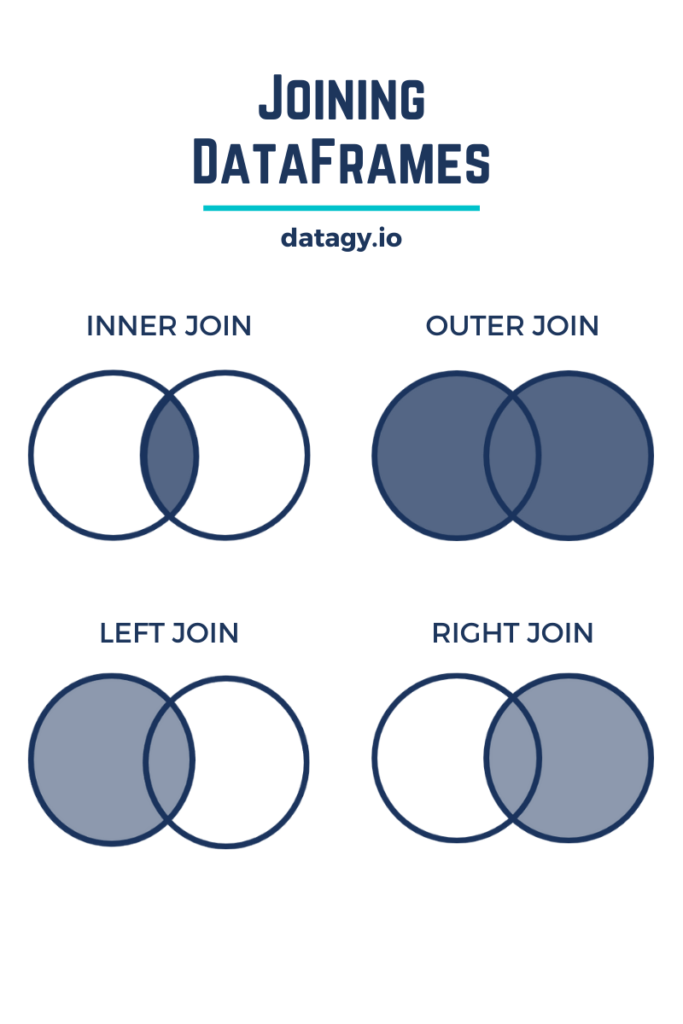


<br>


... But I’m sure you’ll remember this one better:

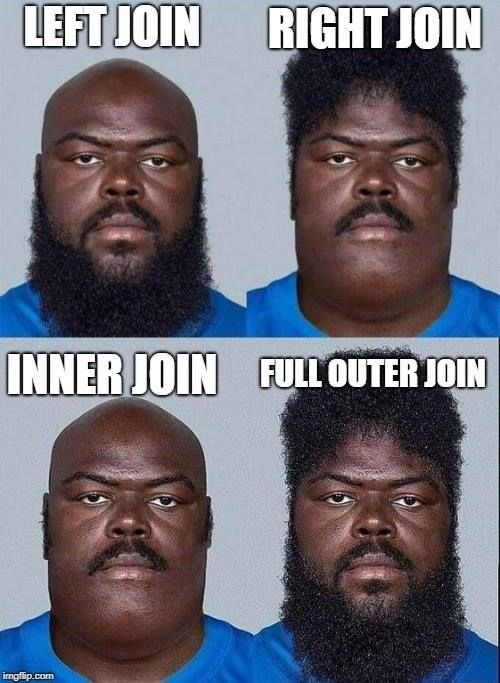

<br>



<br>

### 3.4 Merging on One or Multiple Keys

Pass a list to `on` to merge on **multiple columns at once**. A row only matches if **all key columns** match.


In [10]:

# Scores per user per subject
scores = pd.DataFrame({
    'user_id': [1, 1, 2, 2],
    'subject': ['Math', 'Science', 'Math', 'Science'],
    'score':   [90, 85, 78, 92]
})

# Max possible points per subject
max_points = pd.DataFrame({
    'subject': ['Math', 'Science'],
    'max':     [100, 100]
})

# Merge on a single key
print("Merge on 'subject':")
display(pd.merge(scores, max_points, on='subject'))


Merge on 'subject':


,user_id,subject,score,max
0,1,Math,90,100
1,1,Science,85,100
2,2,Math,78,100
3,2,Science,92,100


In [27]:
# Retakes: a second attempt at a subject for some users
retakes = pd.DataFrame({
    'user_id': [1, 2],
    'subject': ['Math', 'Science'],
    'retake_score': [95, 88]
})

display(scores)
display(retakes)

# Merge on TWO keys: both user_id and subject must match
print("Merge on ['user_id', 'subject']:")
display(pd.merge(scores, retakes, on=['user_id', 'subject'], how='left'))


,user_id,subject,score
0,1,Math,90
1,1,Science,85
2,2,Math,78
3,2,Science,92


,user_id,subject,retake_score
0,1,Math,95
1,2,Science,88


Merge on ['user_id', 'subject']:


,user_id,subject,score,retake_score
0,1,Math,90,95.0
1,1,Science,85,NaN
2,2,Math,78,NaN
3,2,Science,92,88.0



<br>

### 3.5 Validating Merges with `validate`


Unexpected duplicate keys can silently inflate your result by creating unintended duplicate rows. To prevent this, use the validate parameter to check the key relationships before merging. If the data doesn't match your expectations, pandas will fail fast and raise a MergeError.


| Value | Meaning |
|-------|---------|
| `'1:1'` | Keys must be unique in **both** the left and right DataFrames. |
| `'1:m'` | Keys must be unique in the **left** DataFrame only. |
| `'m:1'` | Keys must be unique in the **right** DataFrame only. |


In [20]:

profiles = pd.DataFrame({'user_id': [1, 2, 3], 'name': ['Alice', 'Bob', 'Carol']})
emails   = pd.DataFrame({'user_id': [1, 2, 3], 'email': ['a@x.com', 'b@x.com', 'c@x.com']})

# Each user_id is unique in both — '1:1' passes cleanly
pd.merge(profiles, emails, on='user_id', validate='1:1')


,user_id,name,email
0,1,Alice,a@x.com
1,2,Bob,b@x.com
2,3,Carol,c@x.com


In [22]:

# user_id=1 appears twice in emails — '1:1' will raise an error
emails_dup = pd.DataFrame({'user_id': [1, 1, 2], 'email': ['a@x.com', 'a2@x.com', 'b@x.com']})

# display(profiles)
# display(emails_dup)

try:
    pd.merge(profiles, emails_dup, on='user_id', validate='1:1')
except Exception as e:
    print(type(e).__name__, e)


MergeError Merge keys are not unique in right dataset; not a one-to-one merge



<br>

### 3.6 Common Merge Mistakes

**Duplicate keys → row explosion**

If a key appears multiple times in one or both DataFrames, the merge produces one row for **every matching combination**. The result has more rows than expected.


In [14]:

# user_id=1 has two orders — the merge produces 2 rows for that user
customers = pd.DataFrame({'user_id': [1, 2],    'name':  ['Alice', 'Bob']})
purchases = pd.DataFrame({'user_id': [1, 1, 2], 'item':  ['Laptop', 'Mouse', 'Phone']})

result = pd.merge(customers, purchases, on='user_id')
print(f"customers rows: {len(customers)}, purchases rows: {len(purchases)}, merged rows: {len(result)}")
display(result)


customers rows: 2, purchases rows: 3, merged rows: 3


,user_id,name,item
0,1,Alice,Laptop
1,1,Alice,Mouse
2,2,Bob,Phone


<br>


**Missing keys → silent data loss (inner join) or unexpected NaNs (left/outer join)**

With `how='inner'` (default), rows whose key doesn't appear in the other DataFrame are **silently dropped**. If you expect all rows to match, switch to a `left` or `outer` join and inspect the NaNs.


In [15]:

employees = pd.DataFrame({'emp_id': [1, 2, 3], 'name': ['Alice', 'Bob', 'Carol']})
salaries  = pd.DataFrame({'emp_id': [1, 2],    'salary': [70000, 80000]})  # Carol is missing

# inner (default) — Carol is silently dropped
print("inner (Carol is gone):")
display(pd.merge(employees, salaries, on='emp_id', how='inner'))

# left — Carol is kept, salary is NaN — makes the gap visible
print("\nleft (Carol kept, NaN salary reveals the gap):")
display(pd.merge(employees, salaries, on='emp_id', how='left'))

# Quick check: how many rows didn't match?
merged = pd.merge(employees, salaries, on='emp_id', how='left')
print(f"\nRows with missing salary: {merged['salary'].isna().sum()}")


inner (Carol is gone):


,emp_id,name,salary
0,1,Alice,70000
1,2,Bob,80000



left (Carol kept, NaN salary reveals the gap):


,emp_id,name,salary
0,1,Alice,70000.0
1,2,Bob,80000.0
2,3,Carol,NaN



Rows with missing salary: 1


<br>

## Conclusions

`.concat()` and `.merge()` are two of the most commonly used tools in pandas for combining datasets. They cover most everyday use cases: stacking data vertically or horizontally (`concat`) and joining datasets based on keys or relationships (`merge`).

In adition to them, pandas also offers a few other options for specific cases, such as `.join()` and `.combine_first()`.



<br>

## Resources

Repo with a lot of exercises to practice Pandas (Pandas Exercises, guipsamora):
- https://github.com/guipsamora/pandas_exercises
- To practice combining dataframes, see the section "Merge"

